In [128]:
%matplotlib inline

import numpy as np
from roboticstoolbox.robot.ERobot import ERobot
from matplotlib import pyplot
from roboticstoolbox import DHRobot, RevoluteDH, RevoluteMDH
from spatialmath import SE3
import os

<p align="center">
    <img src="./src/robot_description/image.png" alt="robot">
</p>

ERobot: ROBOT, 3 joints (RRR), geometry
┌──────┬───────────────┬───────┬────────┬───────────────────────────────────────────┐
│ link │     link      │ joint │ parent │            ETS: parent to link            │
├──────┼───────────────┼───────┼────────┼───────────────────────────────────────────┤
│    0 │ link_0        │       │ BASE   │ SE3()                                     │
│    1 │ link_1        │     0 │ link_0 │ SE3(0, 0, 0.2) ⊕ Rz(q0)                   │
│    2 │ link_2        │     1 │ link_1 │ SE3(0, -0.12, 0; 0°, -90°, -90°) ⊕ Rz(q1) │
│    3 │ link_3        │     2 │ link_2 │ SE3(0.25, 0, 0.1) ⊕ Rz(q2)                │
│    4 │ @end_effector │       │ link_3 │ SE3(0.28, 0, 0; 90°, -0°, 90°)            │
└──────┴───────────────┴───────┴────────┴───────────────────────────────────────────┘

┌──────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2  │
├──────┼─────┼─────┼─────┤
│   qz │  0° │  0° │  0° │
└──────┴─────┴─────┴─────┘


Forward kinematics at zero configuration:
   1  

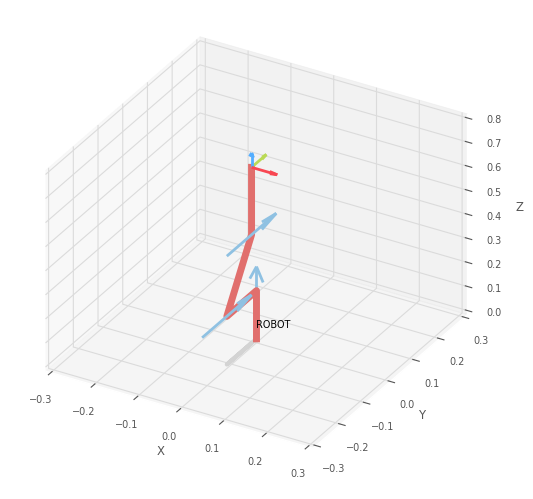

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [129]:
class MyRobot(ERobot):
    def __init__(self):
        # Get the current working directory and construct the path to the URDF file
        current_dir = os.getcwd()
        urdf_path = os.path.join(current_dir, "src/robot_description/urdf/my-robot.xacro")
        
        links, name, urdf_string, urdf_filepath = ERobot.URDF_read(urdf_path)
        super().__init__(
            links,
            name=name.upper(),
            manufacturer="",
            urdf_string=urdf_string,
            urdf_filepath=urdf_filepath,
        )

        self.qz = np.zeros(self.n)
        self.addconfiguration("qz", self.qz)

robot = MyRobot()
print(robot)
print("\nForward kinematics at zero configuration:")
print(robot.fkine(robot.qz))

robot.plot([0,0,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])


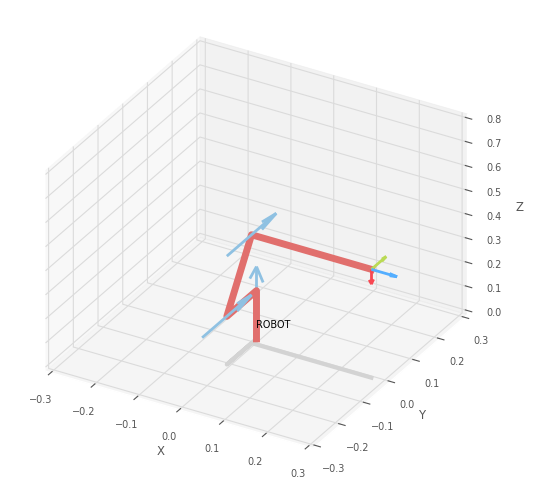

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [130]:
# tesing move joints at joint 3 at -90 degree
robot.qz = [0, 0, np.pi/2]
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

In [131]:
T = robot.fkine(robot.qz)
current_pos = T.t
target_pos = np.array([0.2, 0.3, 0.5])
# Compute position error
error = target_pos - current_pos
error_norm = np.linalg.norm(error)
print("Current Position:", current_pos)
print("Target Position:", target_pos)
print("Position Error:", error)
print("Error Norm:", error_norm)


Current Position: [ 0.27999987 -0.01999996  0.45000013]
Target Position: [0.2 0.3 0.5]
Position Error: [-0.07999987  0.31999996  0.04999987]
Error Norm: 0.3336164564722086


Arrived at the target position at iteration 241!


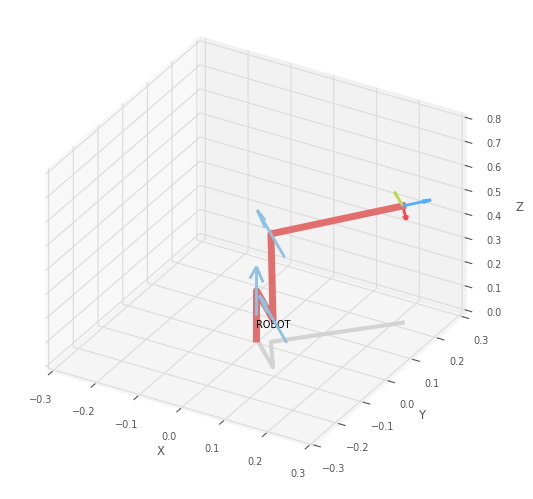

Total simulation time: 2.410s
Total iterations: 241
Final position: [0.22368854 0.20434765 0.4850442 ]
Target position: [0.2 0.3 0.5]
Final error: 0.099670


<Figure size 640x480 with 0 Axes>

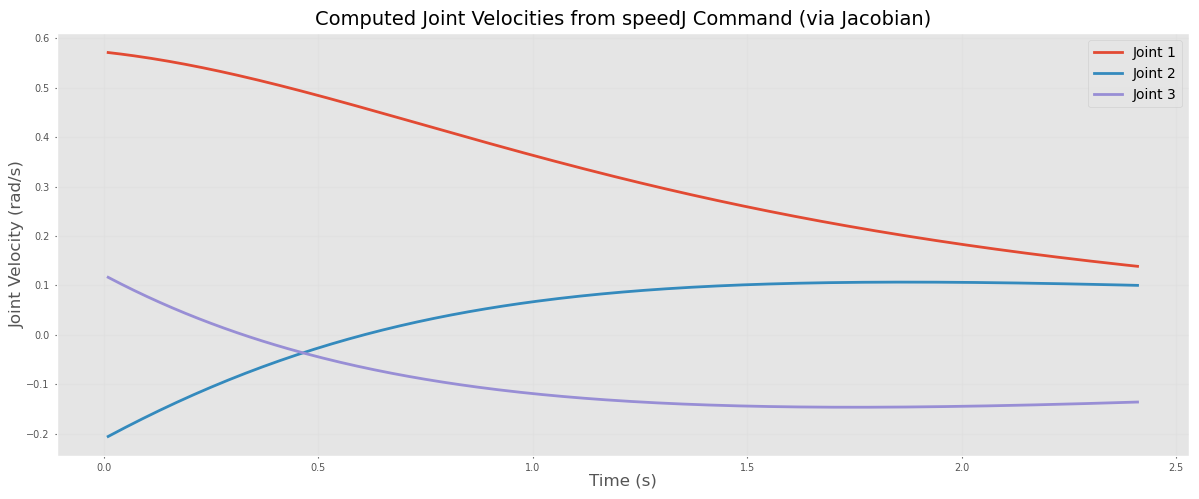

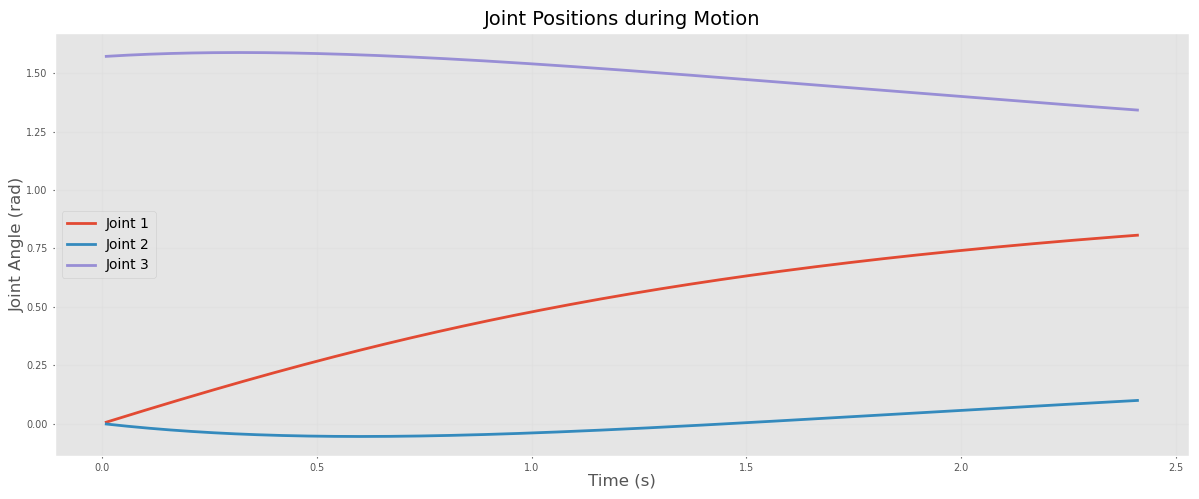

In [132]:
import matplotlib.pyplot as plt

arrived = False
dt = 0.01  # Fixed time step (simulation time, not real time)
computed_joint_velocities = []
joint_positions = []
time_stamps = []                 # Record the cumulative simulation time for each iteration
cumulative_time = 0.0            # Track total elapsed time
max_iterations = 10000           # Safety limit to prevent infinite loop
threshold = 0.1                  # Position error threshold for arrival
iteration = 0
while not arrived and iteration < max_iterations:
    T = robot.fkine(robot.qz)
    current_pos = T.t
    
    # Compute position error
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)
    
    if error_norm < threshold:
        arrived = True
        print(f"Arrived at the target position at iteration {iteration}!")
        break
    
    # Simple proportional controller for velocity
    Kp = 0.5
    v = Kp * error
    
    # Compute Jacobian at current configuration
    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]  # Position part only

    condJ = np.linalg.cond(J_pos)
    if condJ > 1e12:
        print(f"Warning: Jacobian is ill-conditioned (cond={condJ:.2e}) at iteration {iteration}.")
        break

    # Compute joint velocities using the position-only Jacobian
    qd = np.linalg.pinv(J_pos) @ v

    # Update joint angles
    robot.qz = robot.qz + qd * dt
    # Store data for plotting
    computed_joint_velocities.append(qd)
    joint_positions.append(robot.qz.copy())
    cumulative_time += dt
    time_stamps.append(cumulative_time)
    
    iteration += 1

if iteration >= max_iterations and not arrived:
    print("Reached maximum iterations without meeting the error threshold.")
    
# Convert the lists to numpy arrays for plotting
if computed_joint_velocities:
    computed_joint_velocities = np.array(computed_joint_velocities)
else:
    computed_joint_velocities = np.zeros((0, robot.n))
if joint_positions:
    joint_positions = np.array(joint_positions)
else:
    joint_positions = np.zeros((0, robot.n))
    
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])
print(f"Total simulation time: {cumulative_time:.3f}s")
print(f"Total iterations: {len(time_stamps)}")
print(f"Final position: {robot.fkine(robot.qz).t}")
print(f"Target position: {target_pos}")
print(f"Final error: {np.linalg.norm(target_pos - robot.fkine(robot.qz).t):.6f}")

# --- Plotting the Computed Joint Velocities ---
plt.figure(figsize=(12, 5))
if len(time_stamps) and computed_joint_velocities.size:
    num_joints = computed_joint_velocities.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, computed_joint_velocities[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint velocity data recorded', ha='center', va='center')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Joint Velocity (rad/s)", fontsize=12)
plt.title("Computed Joint Velocities from speedJ Command (via Jacobian)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plotting the Joint Positions ---
plt.figure(figsize=(12, 5))
if len(time_stamps) and joint_positions.size:
    num_joints = joint_positions.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, joint_positions[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint position data recorded', ha='center', va='center')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Joint Angle (rad)", fontsize=12)
plt.title("Joint Positions during Motion", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


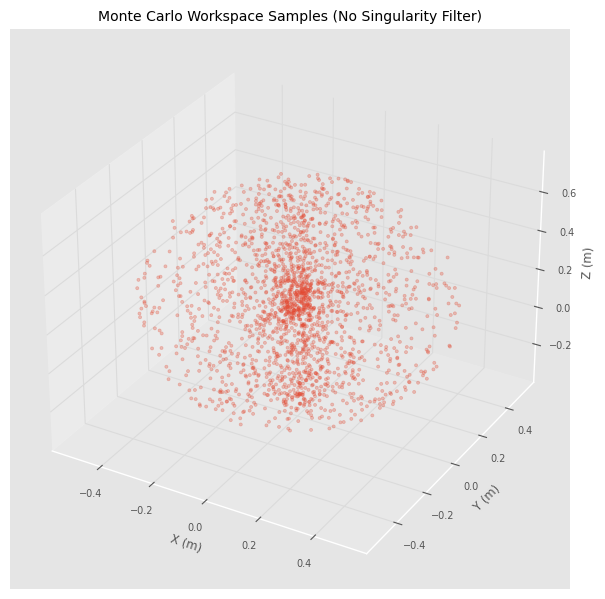

Sampled 2000 joint configurations
Min radius: 0.027 m, Max radius: 0.730 m
Z-range: -0.330 m to 0.730 m


In [133]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 for 3D plotting

num_samples = 2000
qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
lower = qlim[:, 0]
upper = qlim[:, 1]

# Randomly sample joint configurations within joint limits
rand = np.random.uniform(size=(num_samples, robot.n))
q_samples = lower + rand * (upper - lower)
positions = []
for q in q_samples:
    T = robot.fkine(q)
    positions.append(np.array(T.t).reshape(-1))

positions = np.array(positions)
radii = np.linalg.norm(positions, axis=1)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], s=5, alpha=0.3)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Monte Carlo Workspace Samples (No Singularity Filter)')
plt.tight_layout()
plt.show()

print(f'Sampled {num_samples} joint configurations')
print(f'Min radius: {radii.min():.3f} m, Max radius: {radii.max():.3f} m')
print(f'Z-range: {positions[:, 2].min():.3f} m to {positions[:, 2].max():.3f} m')

# Save sampled positions/configurations for reuse
sampled_positions = positions.copy()
sampled_configs = q_samples.copy()


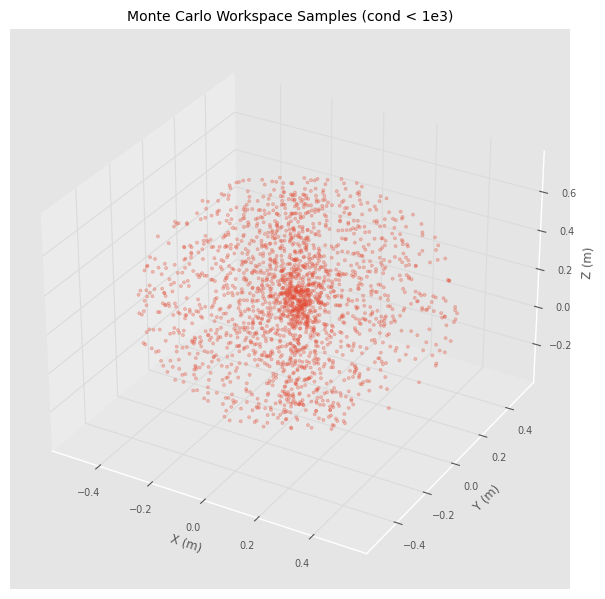

Sampled 2000 joint configurations
Valid samples (cond < 1e+03): 1998
Min radius: 0.021 m, Max radius: 0.730 m
Z-range: -0.330 m to 0.729 m


In [134]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 for 3D plotting

num_samples = 2000
qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
lower = qlim[:, 0]
upper = qlim[:, 1]

rand = np.random.uniform(size=(num_samples, robot.n))
q_samples = lower + rand * (upper - lower)
positions = []
valid_q = []
cond_threshold = 1e3
for q in q_samples:
    J = robot.jacob0(q)
    J_pos = J[:3, :]
    condJ = np.linalg.cond(J_pos)
    if condJ > cond_threshold:
        continue
    T = robot.fkine(q)
    positions.append(np.array(T.t).reshape(-1))
    valid_q.append(q)

positions = np.array(positions)
valid_q = np.array(valid_q)
radii = np.linalg.norm(positions, axis=1) if len(positions) else np.array([])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
if len(positions):
    ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], s=5, alpha=0.3)
else:
    ax.text(0.5, 0.5, 0.5, 'No samples below condition threshold', ha='center', va='center')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Monte Carlo Workspace Samples (cond < 1e3)')
plt.tight_layout()
plt.show()

print(f'Sampled {num_samples} joint configurations')
print(f'Valid samples (cond < {cond_threshold:.0e}): {len(positions)}')
if len(positions):
    print(f'Min radius: {radii.min():.3f} m, Max radius: {radii.max():.3f} m')
    print(f'Z-range: {positions[:, 2].min():.3f} m to {positions[:, 2].max():.3f} m')
else:
    print('No valid samples below threshold; try increasing cond_threshold or samples.')

# Save filtered samples as well
filtered_positions = positions.copy()
filtered_configs = valid_q.copy()


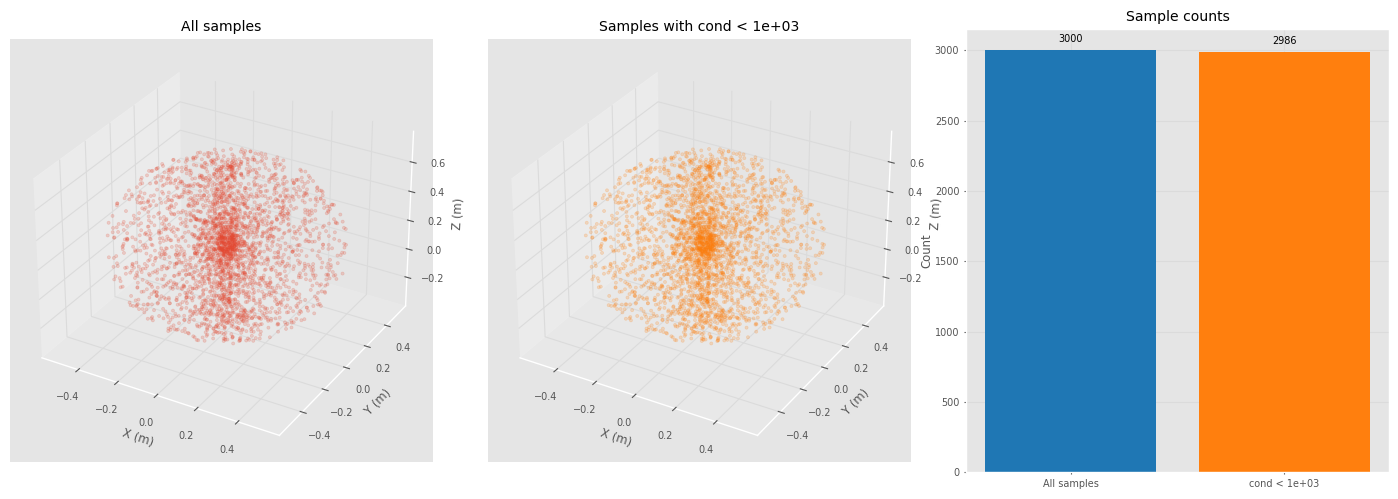

Total samples: 3000
Filtered samples: 2986 (cond < 1e+03)


In [135]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 for 3D plotting

num_samples = 3000
qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
lower = qlim[:, 0]
upper = qlim[:, 1]

rand = np.random.uniform(size=(num_samples, robot.n))
q_samples = lower + rand * (upper - lower)

positions_all = []
positions_filtered = []
cond_threshold = 1e3

for q in q_samples:
    T = robot.fkine(q)
    pos = np.array(T.t).reshape(-1)
    positions_all.append(pos)

    J = robot.jacob0(q)
    J_pos = J[:3, :]
    condJ = np.linalg.cond(J_pos)
    if condJ <= cond_threshold:
        positions_filtered.append(pos)

positions_all = np.array(positions_all)
positions_filtered = np.array(positions_filtered)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(positions_all[:, 0], positions_all[:, 1], positions_all[:, 2], s=5, alpha=0.2)
ax1.set_title('All samples')
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')

ax2 = fig.add_subplot(132, projection='3d')
if len(positions_filtered):
    ax2.scatter(positions_filtered[:, 0], positions_filtered[:, 1], positions_filtered[:, 2], s=5, alpha=0.2, color='tab:orange')
else:
    ax2.text(0.5, 0.5, 0.5, 'No samples below condition threshold', ha='center', va='center')
ax2.set_title(f'Samples with cond < {cond_threshold:.0e}')
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')

ax3 = fig.add_subplot(133)
bars = [num_samples, len(positions_filtered)]
labels = ['All samples', f'cond < {cond_threshold:.0e}']
ax3.bar(labels, bars, color=['tab:blue', 'tab:orange'])
ax3.set_ylabel('Count')
ax3.set_title('Sample counts')
ax3.set_ylim(0, num_samples * 1.05)
for i, val in enumerate(bars):
    ax3.text(i, val + num_samples * 0.02, str(val), ha='center')

plt.tight_layout()
plt.show()

print(f'Total samples: {num_samples}')
print(f'Filtered samples: {len(positions_filtered)} (cond < {cond_threshold:.0e})')


In [136]:
import numpy as np
import matplotlib.pyplot as plt


def run_ipk_test(target_pos, q0, dt=0.01, kp=0.5, threshold=0.01, max_iterations=5000, cond_limit=1e6):
    robot.qz = np.array(q0)
    arrived = False
    cumulative_time = 0.0
    time_stamps = []
    joint_traj = []
    cond_hist = []

    for iteration in range(max_iterations):
        T = robot.fkine(robot.qz)
        current_pos = T.t
        error = target_pos - current_pos
        error_norm = np.linalg.norm(error)

        if error_norm < threshold:
            arrived = True
            break

        J = robot.jacob0(robot.qz)
        J_pos = J[:3, :]
        condJ = np.linalg.cond(J_pos)
        cond_hist.append(condJ)
        if condJ > cond_limit:
            print(f"Iteration {iteration}: Jacobian ill-conditioned (cond={condJ:.2e})")
            break

        v = kp * error
        qd = np.linalg.pinv(J_pos) @ v
        robot.qz = robot.qz + qd * dt

        cumulative_time += dt
        time_stamps.append(cumulative_time)
        joint_traj.append(robot.qz.copy())

    T_final = robot.fkine(robot.qz)
    return {
        'arrived': arrived,
        'iterations': iteration + 1,
        'time': cumulative_time,
        'final_pos': T_final.t,
        'error_norm': np.linalg.norm(target_pos - T_final.t),
        'time_stamps': np.array(time_stamps),
        'joint_traj': np.array(joint_traj),
        'cond_hist': np.array(cond_hist)
    }


if 'sampled_positions' not in globals() or 'sampled_configs' not in globals() or sampled_positions.size == 0:
    raise ValueError('Run the workspace sampling cell first to populate sampled_positions/sample_configs')

selected_idx = np.random.choice(len(sampled_positions), size=3, replace=False)
targets = [sampled_positions[i] for i in selected_idx]
initial_guesses = [sampled_configs[i] for i in selected_idx]

results = []
for idx, (tgt, q0) in enumerate(zip(targets, initial_guesses), 1):
    result = run_ipk_test(tgt, q0=q0)
    results.append(result)
    print(f"Case {idx}: target={tgt}, arrived={result['arrived']}, iterations={result['iterations']}, error={result['error_norm']:.4f}")

# Plot joint trajectories for the first case
if results and results[0]['joint_traj'].size:
    plt.figure(figsize=(10, 4))
    for j in range(results[0]['joint_traj'].shape[1]):
        plt.plot(results[0]['time_stamps'], results[0]['joint_traj'][:, j], label=f'Joint {j+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Joint angle (rad)')
    plt.title('Joint trajectories (Case 1)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('Case 1 produced no trajectory (likely singular/timeout).')

# Plot condition number history for the first case
if results and results[0]['cond_hist'].size:
    plt.figure(figsize=(8, 3))
    plt.plot(results[0]['cond_hist'])
    plt.xlabel('Iteration')
    plt.ylabel('cond(J_pos)')
    plt.title('Jacobian condition number (Case 1)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('Case 1 produced no condition history.')


Case 1: target=[0.05982687 0.29591755 0.51919828], arrived=True, iterations=1, error=0.0000
Case 2: target=[ 0.01882725 -0.03498681  0.38387486], arrived=True, iterations=1, error=0.0000
Case 3: target=[-0.04911296 -0.02289999  0.60335066], arrived=True, iterations=1, error=0.0000
Case 1 produced no trajectory (likely singular/timeout).
Case 1 produced no condition history.


Solution 1: [ 0.5532098  -0.23088874  1.77799023]


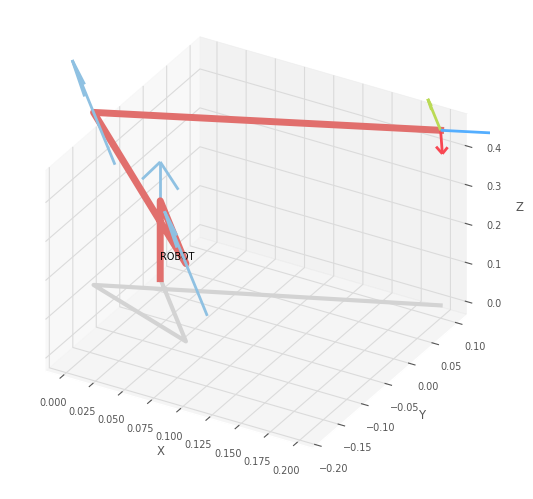

Solution 2: [-2.76751027  0.23089005 -1.77799097]


<Figure size 640x480 with 0 Axes>

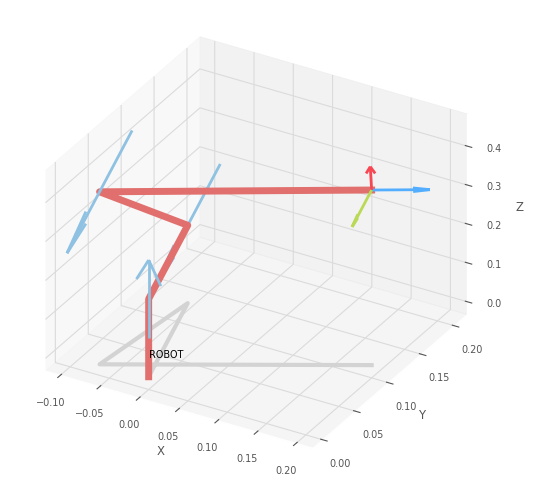

Solution 3: [ 0.55321108  1.68635589 -1.77799096]


<Figure size 640x480 with 0 Axes>

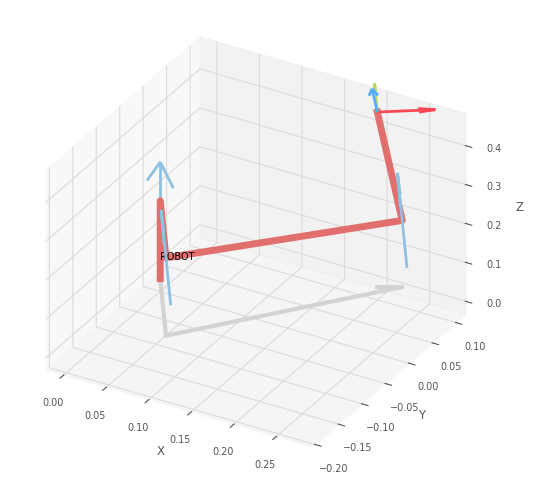

Solution 4: [-2.76751027 -1.68635473  1.77799098]


<Figure size 640x480 with 0 Axes>

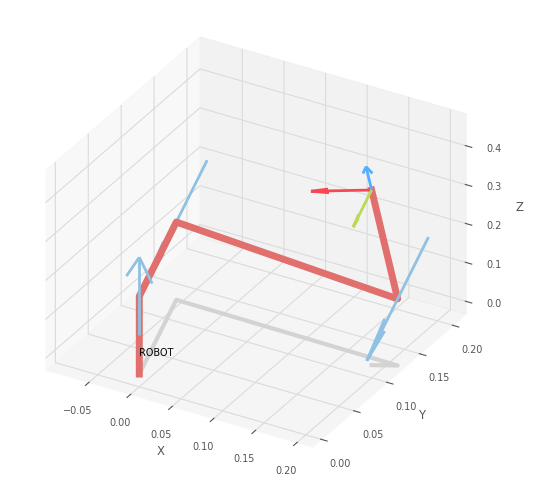

<Figure size 640x480 with 0 Axes>

In [137]:
import numpy as np
from math import pi
from spatialmath import SE3

target_pos = np.array([0.2, 0.1, 0.45])
ikT_0e = SE3(target_pos[0], target_pos[1], target_pos[2]) @ SE3.Rx(np.pi/2)

# Discover multiple IK solutions by randomising the initial guess
sol_check = []

qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
ql_lower = qlim[:, 0]
ql_upper = qlim[:, 1]

def within_limits(q):
    return np.all(q >= ql_lower) and np.all(q <= ql_upper)


def are_same_postures(sol1, sol2, threshold=1e-2):
    return np.allclose(sol1, sol2, atol=threshold)

max_attempts = 30
distinct_solutions = []

for attempt in range(max_attempts):
    q_guess = np.random.uniform(low=-pi, high=pi, size=robot.n)
    try:
        sol = robot.ikine_LM(ikT_0e, q0=q_guess, mask=[1, 1, 1, 0, 0, 0])
    except Exception as exc:
        print(f'Attempt {attempt+1}: IK exception -> {exc}')
        continue

    if not getattr(sol, 'success', False):
        continue

    q_sol = np.array(sol.q).flatten()
    if not within_limits(q_sol):
        continue

    if not any(are_same_postures(q_sol, existing) for existing in distinct_solutions):
        distinct_solutions.append(q_sol)

if not distinct_solutions:
    print('No distinct IK solutions found (try increasing max_attempts).')
else:
    for idx, sol in enumerate(distinct_solutions, 1):
        print(f'Solution {idx}: {sol}')
        sol_check.append(sol)
        try:
            robot.plot(sol, backend='pyplot', block=False)
        except Exception as exc:
            print(f'Plot failed for solution {idx}: {exc}')

